# Data Comparison

**Yueying Sun**

April 2026

In this notebook, we compare different data sources for U.S. bond and equity capitalisation. 
Specifically, we use Flow of Funds (FoF) and MSPD data for Treasury securities, and FoF and CRSP data for equities. 
The aim is to assess the consistency across datasets and verify whether they exhibit similar dynamics over time.

First, we import all modules that we need. 

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn
seaborn.set()

## Comparison of U.S. Treasury securities: FoF vs MSPD

We obtain U.S. Treasury securities data from two sources: the Flow of Funds (FoF) and the Monthly Statement of the Public Debt (MSPD). FoF reports data on a quarterly basis, while MSPD provides monthly observations. 
In both datasets, datas are reported in millions of U.S. dollars.

1. Loading UST data from US Fiscal data (MSPD)

In [2]:
USTdata = pd.read_csv('MSPD_SumSecty.csv')
#pd.read_csv('/Users/yueyingsun/Desktop/MSPD_SumSecty_20010131_20230430.csv')

In [3]:
USTdata['Record Date'] = pd.to_datetime(USTdata['Record Date'])

In [4]:
USTdata.sort_values(by='Record Date', inplace = True)

In [5]:
USTdata = USTdata.set_index('Record Date')

2. Loading UST data from Flow of Funds (FoF) 

In [6]:
FoF_UTSdata = pd.read_csv('FoF_L210_TreasurySecurites.csv')
#pd.read_csv('/Users/yueyingsun/Documents/fof_data/FoF_L210_TreasurySecurites.csv')

In [7]:
FoF_UTSdata = FoF_UTSdata.T
FoF_UTSdata.rename(columns=FoF_UTSdata.iloc[0], inplace = True)
FoF_UTSdata = FoF_UTSdata.iloc[6:]

In [8]:
#turn Q1-Q4 to the quarterly end date
FoF_UTSdata.index = pd.PeriodIndex(FoF_UTSdata.index, freq='Q').to_timestamp() + pd.offsets.QuarterEnd()

### Marketable securities

(Comparison of marketable securities: MSPD vs FoF)

In [9]:
UST_markable = USTdata.loc[USTdata['Security Type Description'] == 'Total Marketable']['Total Public Debt Outstanding (in Millions)']

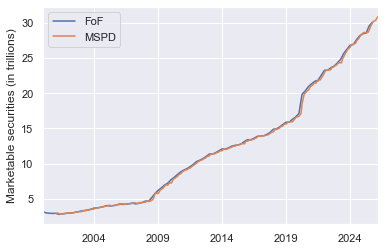

In [10]:
(FoF_UTSdata.loc['2000':, 'Federal government; total marketable Treasury securities; liability'] / 1e6).plot()
(UST_markable / 1e6).plot();
plt.legend(['FoF','MSPD']);
plt.ylabel('Marketable securities (in trillions)');
plt.xlabel('');
#plt.savefig('UST_marketable.png');

Difference between two datasets on the marketable securites

In [11]:
markable_error = UST_markable - FoF_UTSdata['Federal government; total marketable Treasury securities; liability']
markable_error = markable_error.dropna()

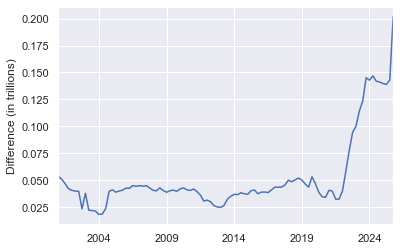

In [12]:
(markable_error / 1e6).plot();
plt.ylabel('Difference (in trillions)');

The two datasets are closely aligned in levels. 
Although there are non-negligible differences, these remain small relative to the total level of marketable securities, generally well below 1\%. 
Therefore, the two data sources exhibit highly similar dynamics.

### Nonmarketable securities

(Comparison of marketable securities: MSPD vs FoF)

In [13]:
UST_nonmarkable = USTdata.loc[USTdata['Security Type Description'] == 'Total Nonmarketable']['Total Public Debt Outstanding (in Millions)']

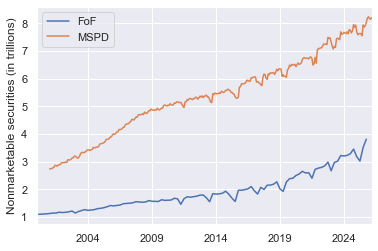

In [14]:
(FoF_UTSdata.loc['2000':, 'Federal government; total nonmarketable Treasury securities; liability']/ 1e6).plot();
(UST_nonmarkable / 1e6).plot();
plt.legend(['FoF','MSPD']);
plt.ylabel('Nonmarketable securities (in trillions)');
plt.xlabel('');
plt.savefig('UST_nonmarketable.png');

U.S. Treasury securities are typically classified into marketable and nonmarketable components. 
The two datasets exhibit a very similar overall trend in total Treasury securities. 
This is consistent with the observation that the marketable components are closely aligned across the two sources, 
while larger discrepancies are observed in the nonmarketable component.

## Comparison of equity capitalisation: FoF vs CRSP

We compare equity capitalisation using data from the Flow of Funds (FoF) and CRSP. Specifically, we consider two measures from CRSP: total shares and common shares, and two measures from the Flow of Funds (FoF): total corporate equity and domestic corporate equity.

In CRSP, datas are reported in thousands of U.S. dollars and in FoF, datas are reported in millions of U.S. dollars.

1. Obtain the market capitalisation of common shares by summing market capitalisation across all common stocks in CRSP


In [15]:
import wrds

In [16]:
wrds_login = 'rennie97'
db = wrds.Connection(wrds_username=wrds_login)

Loading library list...
Done


In [17]:
%%time

df = db.raw_sql("""SELECT mthcaldt, SUM(mthcap) AS total_mthcap
                FROM crsp.StkMthSecurityData 
                WHERE sharetype = 'NS' AND securitysubtype = 'COM' 
                AND mthcaldt BETWEEN '2001-01-01' AND '2025-12-31'
                AND issuertype IN ('ACOR','CORP') AND usincflg = 'Y'
                GROUP BY mthcaldt
                """, date_cols='mthcaldt')

CPU times: user 12.8 ms, sys: 3.84 ms, total: 16.6 ms
Wall time: 4.5 s


In [18]:
#concatinate a line as the monthly mktcap means the mktcap one month ahead
tmp = pd.DataFrame(np.nan, index=[pd.to_datetime('2000-12-31')], columns = df.columns)
df = pd.concat([tmp,df])

#move everything one row ahead and remove the last row
df = df.shift(-1).iloc[:-1]

In [19]:
df['mthcaldt'] = pd.to_datetime(df['mthcaldt'])
df.set_index('mthcaldt', inplace = True)
CRSP_common = df / 1e9 #All values are converted to trillions of U.S. dollars.

2. Obtain the total equity market capitalisation by summing market capitalisation across all stocks in CRSP

In [20]:
%%time

dff = db.raw_sql("""SELECT mthcaldt, SUM(mthcap) AS total_mthcap
                FROM crsp.StkMthSecurityData 
                WHERE mthcaldt BETWEEN '2001-01-01' AND '2025-12-31'
                GROUP BY mthcaldt
                """, date_cols='mthcaldt')

CPU times: user 10.6 ms, sys: 2.24 ms, total: 12.9 ms
Wall time: 1.39 s


In [21]:
#concatinate a line as the monthly mktcap means the mktcap one month ahead
tmp = pd.DataFrame(np.nan, index=[pd.to_datetime('2000-12-31')], columns = dff.columns)
dff = pd.concat([tmp,dff])

#move everything one row ahead and remove the last row
dff = dff.shift(-1).iloc[:-1]

In [22]:
dff['mthcaldt'] = pd.to_datetime(dff['mthcaldt'])
dff.set_index('mthcaldt', inplace = True)
CRSP_total = dff / 1e9

3. Obtain the FoF total corporate equity (All sectors) from FoF data

In [23]:
FoF_CEdata = pd.read_csv('FoF_L224_CorporateEquities.csv')
#pd.read_csv('/Users/yueyingsun/Documents/fof_data/FoF_L223_CorporateEquities.csv')
FoF_CEdata = FoF_CEdata.T
FoF_CEdata.rename(columns=FoF_CEdata.iloc[0], inplace = True)
FoF_CEdata = FoF_CEdata.iloc[6:]
FoF_CEdata.index = pd.PeriodIndex(FoF_CEdata.index, freq='Q').to_timestamp() + pd.offsets.QuarterEnd()

In [24]:
#there is one duplicated column
FoF_CEdata = FoF_CEdata.loc[:,~FoF_CEdata.columns.duplicated()]
FoF_CEtotal = (FoF_CEdata['All sectors; corporate equities; asset']) / 1e6

4. Obtain the FoF total corporate equity (domestic) from FoF data

In [25]:
FoF_CEdomestic = (FoF_CEdata['All sectors; corporate equities; asset'] - FoF_CEdata['Rest of the world; U.S. corporate equities; asset']) / 1e6

### Equity capitalisation plots

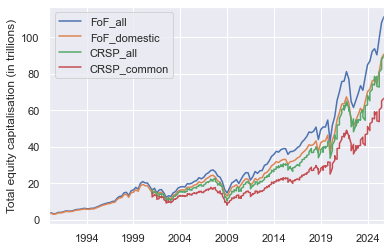

In [26]:
plt.figure()
ax = plt.gca()
FoF_CEtotal.plot(ax = ax);
FoF_CEdomestic.plot(ax = ax);
CRSP_total.plot(ax = ax);
CRSP_common.plot(ax = ax);
plt.ylabel('Total equity capitalisation (in trillions)');
plt.xlabel('');
plt.legend(['FoF_all', 'FoF_domestic', 'CRSP_all', 'CRSP_common']);
#plt.tight_layout()
#plt.show()
plt.savefig('Equity_comparison.png');

All four series display very similar time-series dynamics, capturing the same major fluctuations in equity capitalisation over the sample period. In particular, the FoF domestic equity series is closely aligned with the CRSP total market capitalisation. This suggests that, despite differences in construction, both measures capture broadly similar underlying equity exposure. 

This supports our choice of using the FoF domestic equity data in the empirical analysis section.